# 01. Exploratory Data Analysis - Exploratory Data Overview. Initial look at the dataset: distributions, outliers, basic relationships, and sanity checks.

# 1. Importing labrieries and loading data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import scipy.stats as stats
from matplotlib.gridspec import GridSpec

In [3]:
BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, "data", "House_Rate_Data.csv" )
df = pd.read_csv(DATA_PATH)

# 2. Basic data overwiev

In [4]:
#a) structure:
print("===== STRUCTURE =====")

print("\nInfo:")
print(df.info())

print("\nShape (rows, columns):")
print(df.shape)

print("\nHead:")
display(df.head())

print("\nDtypes:")
print(df.dtypes)

#b) quality 

print("\n===== QUALITY =====")

print("\nDescribe:")
display(df.describe())

print("\nMissing values (count):")
print(df.isnull().sum)

print("\nMissing values (%):")
print(df.isnull().mean() * 100)

print("\nNumber of duplicates:")
print(df.duplicated().sum())

print("\nUnique values per column:")
print(df.nunique())

#c) numerical and categorical columns comparison

print("\nNumerical Columns:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(list(numerical_cols))

print("\nCategorical Columns:")
categorical_cols = df.select_dtypes(include=object).columns
print(list(categorical_cols))

#d) random check value in column:

print("\nParticular features in 'View' column:")
print(df['view'].unique())
print("\nThe number of each features in column 'view':")
print(df['view'].value_counts())

===== STRUCTURE =====

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4600 non-null   object 
 1   Rates or Price  4600 non-null   float64
 2   Bedrooms        4600 non-null   int64  
 3   Bathrooms       4600 non-null   float64
 4   Sqft_Living     4600 non-null   int64  
 5   Sqft_lot        4600 non-null   int64  
 6   Floors          4600 non-null   float64
 7   Waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   Condition       4600 non-null   int64  
 10  Sqft_Above      4600 non-null   int64  
 11  Sqft_Basement   4600 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 431.4+ KB
None

Shape (rows, columns):
(4600, 12)

Head:


,Date,Rates or Price,Bedrooms,Bathrooms,Sqft_Living,Sqft_lot,Floors,Waterfront,view,Condition,Sqft_Above,Sqft_Basement
0,02-05-2014,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0
1,02-05-2014,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280
2,02-05-2014,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0
3,02-05-2014,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000
4,02-05-2014,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800



Dtypes:
Date               object
Rates or Price    float64
Bedrooms            int64
Bathrooms         float64
Sqft_Living         int64
Sqft_lot            int64
Floors            float64
Waterfront          int64
view                int64
Condition           int64
Sqft_Above          int64
Sqft_Basement       int64
dtype: object

===== QUALITY =====

Describe:


,Rates or Price,Bedrooms,Bathrooms,Sqft_Living,Sqft_lot,Floors,Waterfront,view,Condition,Sqft_Above,Sqft_Basement
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000



Missing values (count):
<bound method DataFrame.sum of        Date  Rates or Price  Bedrooms  Bathrooms  Sqft_Living  Sqft_lot  \
0     False           False     False      False        False     False   
1     False           False     False      False        False     False   
2     False           False     False      False        False     False   
3     False           False     False      False        False     False   
4     False           False     False      False        False     False   
...     ...             ...       ...        ...          ...       ...   
4595  False           False     False      False        False     False   
4596  False           False     False      False        False     False   
4597  False           False     False      False        False     False   
4598  False           False     False      False        False     False   
4599  False           False     False      False        False     False   

      Floors  Waterfront   view  Condition 

# Note on Numerical Feature Semantics

# All features in this dataset are stored as numeric types; however, their semantic roles differ:
#   Some variables (e.g., Sqft_Living, Sqft_Lot, Sqft_Above, Sqft_Basement) represent continuous numerical quantities.
#   Other variables (e.g., Bedrooms, Bathrooms, Floors, View, Condition, Waterfront) are discrete or ordinal categorical attributes, despite being encoded as integers.

# For modeling purposes, continuous features are treated with scaling and transformation, while ordinal features are handled as ordered categories rather than continuous measurements.

# 3. Univariate


=== Sqft_Living (continuous) ===
count     4600.000000
mean      2139.346957
std        963.206916
min        370.000000
25%       1460.000000
50%       1980.000000
75%       2620.000000
max      13540.000000
Name: Sqft_Living, dtype: float64
Sknewness: 1.724


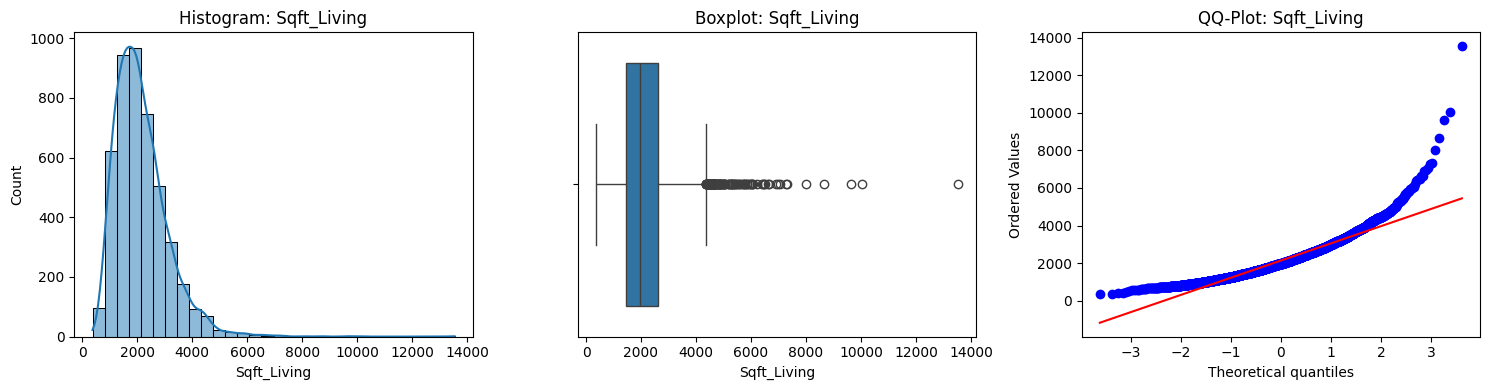


=== Sqft_lot (continuous) ===
count    4.600000e+03
mean     1.485252e+04
std      3.588444e+04
min      6.380000e+02
25%      5.000750e+03
50%      7.683000e+03
75%      1.100125e+04
max      1.074218e+06
Name: Sqft_lot, dtype: float64
Sknewness: 11.307


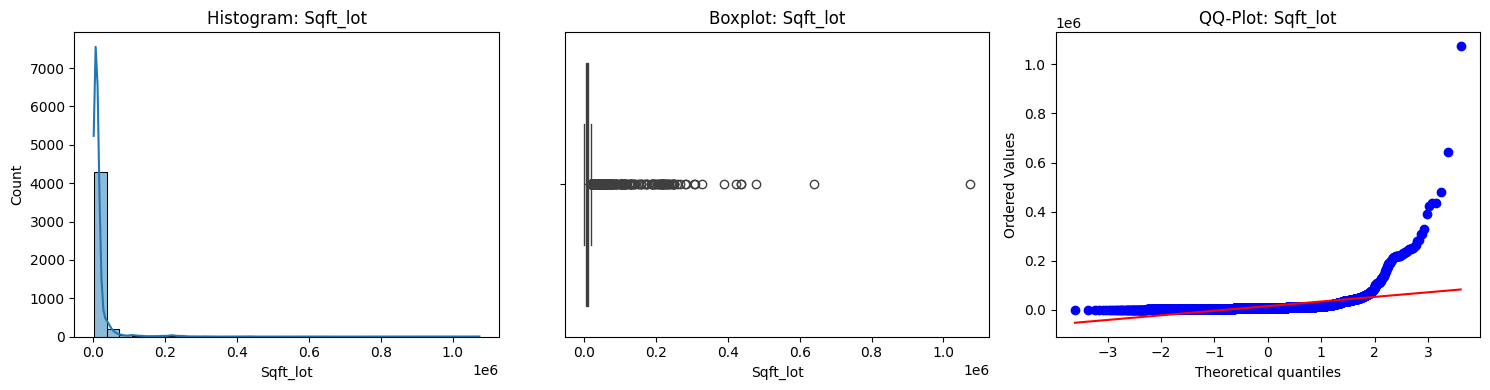


=== Sqft_Above (continuous) ===
count    4600.000000
mean     1827.265435
std       862.168977
min       370.000000
25%      1190.000000
50%      1590.000000
75%      2300.000000
max      9410.000000
Name: Sqft_Above, dtype: float64
Sknewness: 1.494


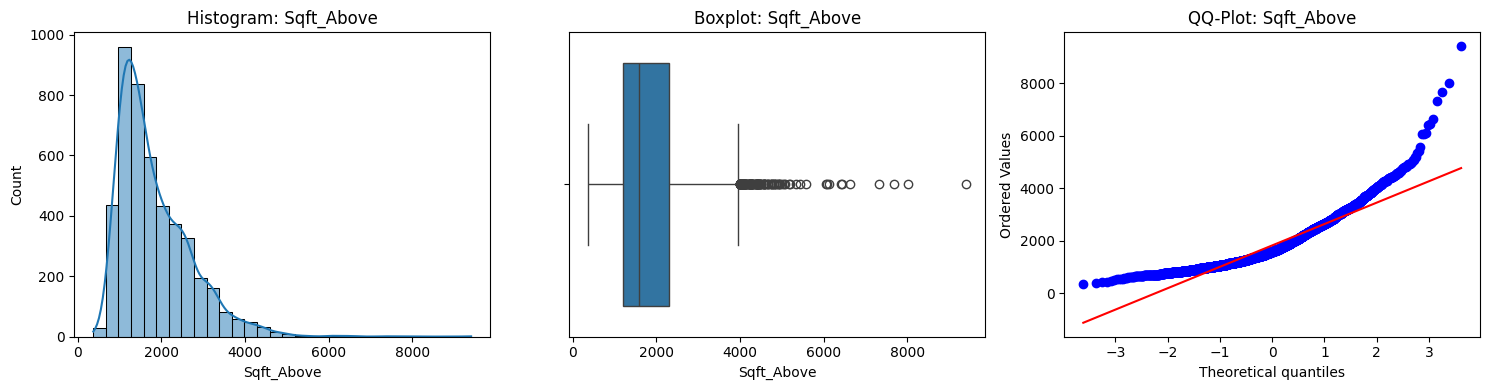


=== Sqft_Basement (continuous) ===
count    4600.000000
mean      312.081522
std       464.137228
min         0.000000
25%         0.000000
50%         0.000000
75%       610.000000
max      4820.000000
Name: Sqft_Basement, dtype: float64
Sknewness: 1.643


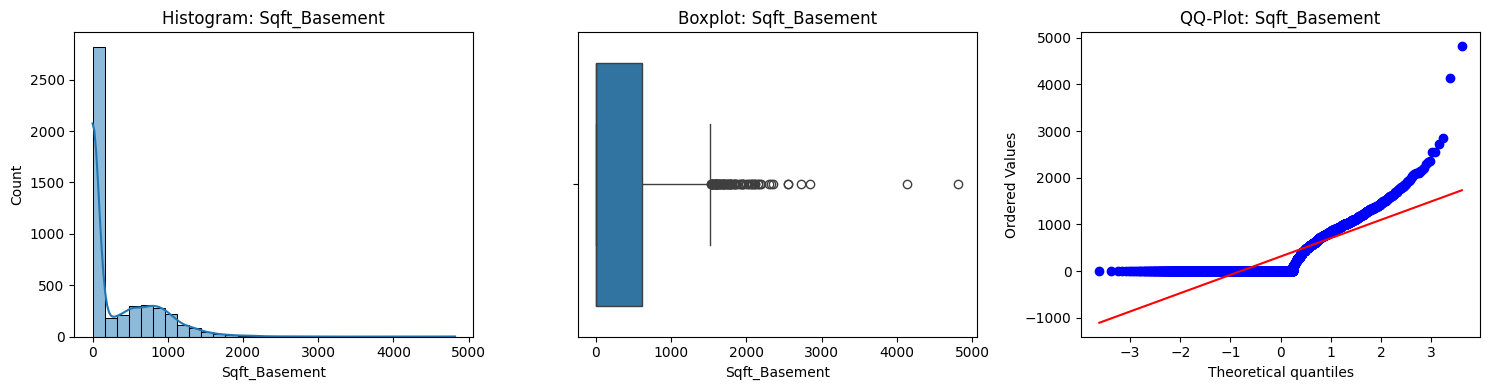


=== Bedrooms (ordinal) ===
Bedrooms
0       2
1      38
2     566
3    2032
4    1531
5     353
6      61
7      14
8       2
9       1
Name: count, dtype: int64
count    4600.000000
mean        3.400870
std         0.908848
min         0.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         9.000000
Name: Bedrooms, dtype: float64


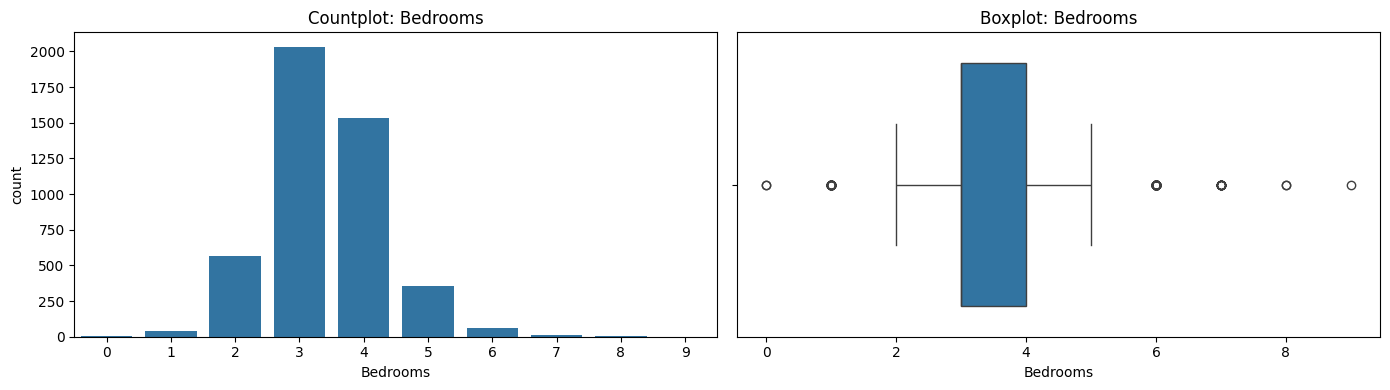


=== Bathrooms (ordinal) ===
Bathrooms
0.00       2
0.75      17
1.00     743
1.25       3
1.50     291
1.75     629
2.00     427
2.25     419
2.50    1189
2.75     276
3.00     167
3.25     136
3.50     162
3.75      37
4.00      23
4.25      23
4.50      29
4.75       7
5.00       6
5.25       4
5.50       4
5.75       1
6.25       2
6.50       1
6.75       1
8.00       1
Name: count, dtype: int64
count    4600.000000
mean        2.160815
std         0.783781
min         0.000000
25%         1.750000
50%         2.250000
75%         2.500000
max         8.000000
Name: Bathrooms, dtype: float64

=== Floors (ordinal) ===
Floors
1.0    2174
1.5     444
2.0    1811
2.5      41
3.0     128
3.5       2
Name: count, dtype: int64
count    4600.000000
mean        1.512065
std         0.538288
min         1.000000
25%         1.000000
50%         1.500000
75%         2.000000
max         3.500000
Name: Floors, dtype: float64


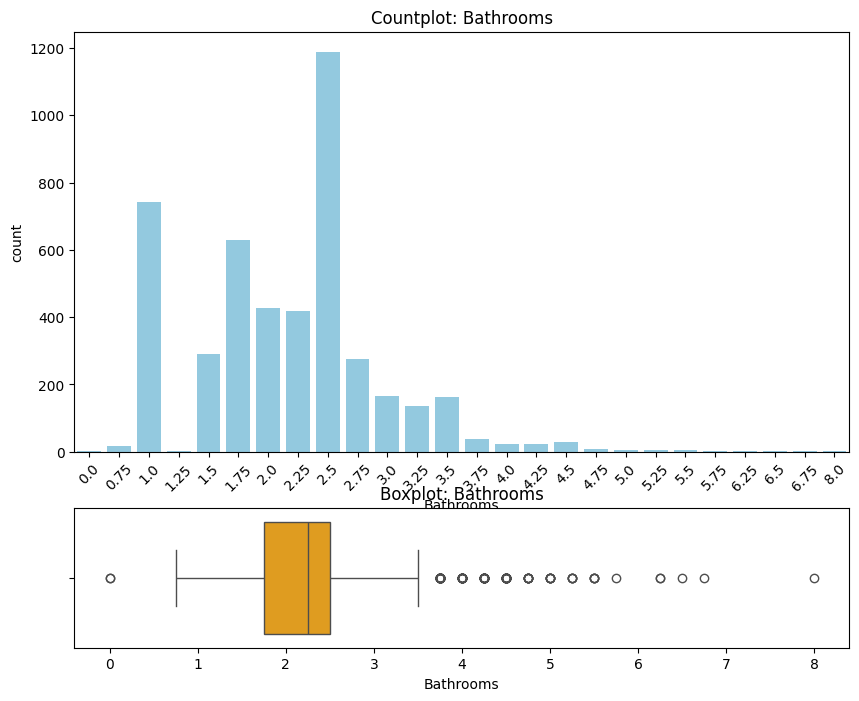

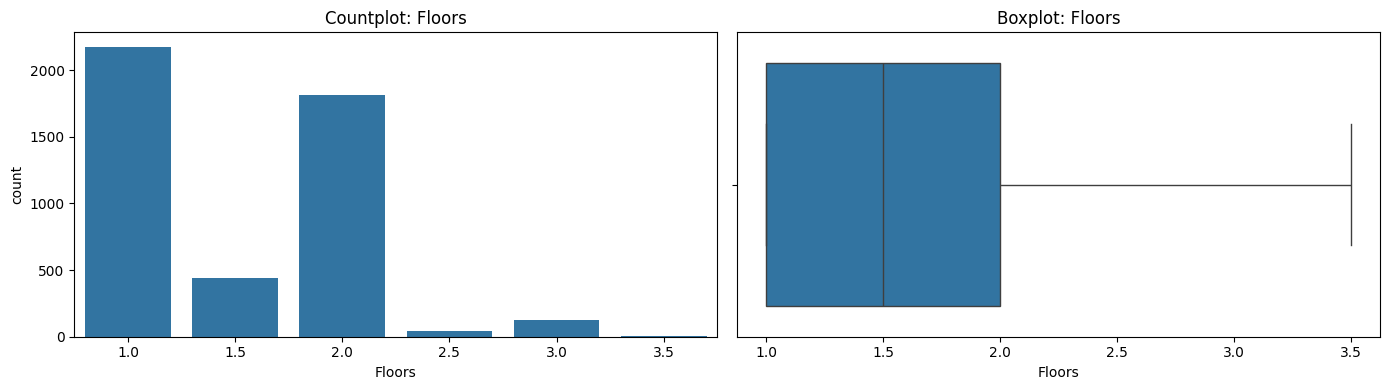


=== view (ordinal) ===
view
0    4140
1      69
2     205
3     116
4      70
Name: count, dtype: int64
count    4600.000000
mean        0.240652
std         0.778405
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.000000
Name: view, dtype: float64


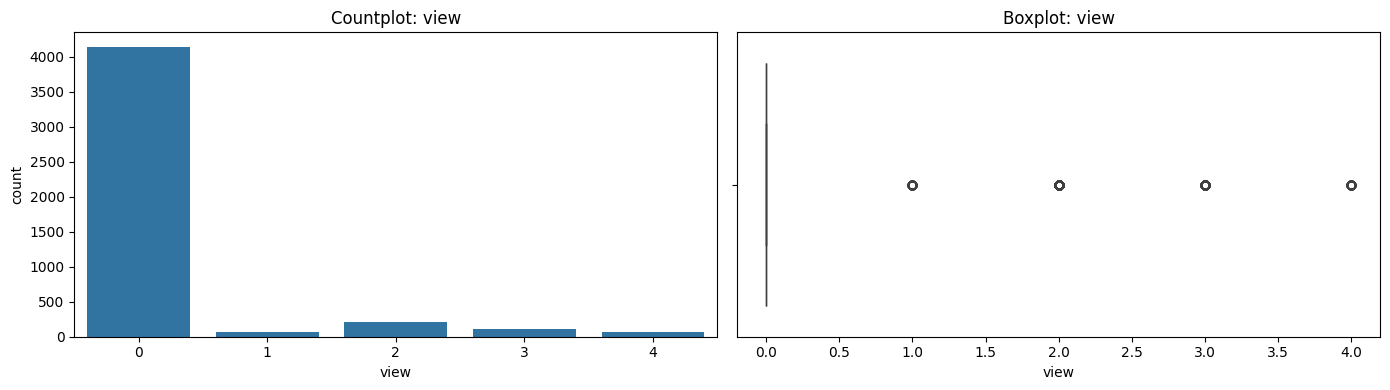


=== Condition (ordinal) ===
Condition
1       6
2      32
3    2875
4    1252
5     435
Name: count, dtype: int64
count    4600.000000
mean        3.451739
std         0.677230
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Condition, dtype: float64


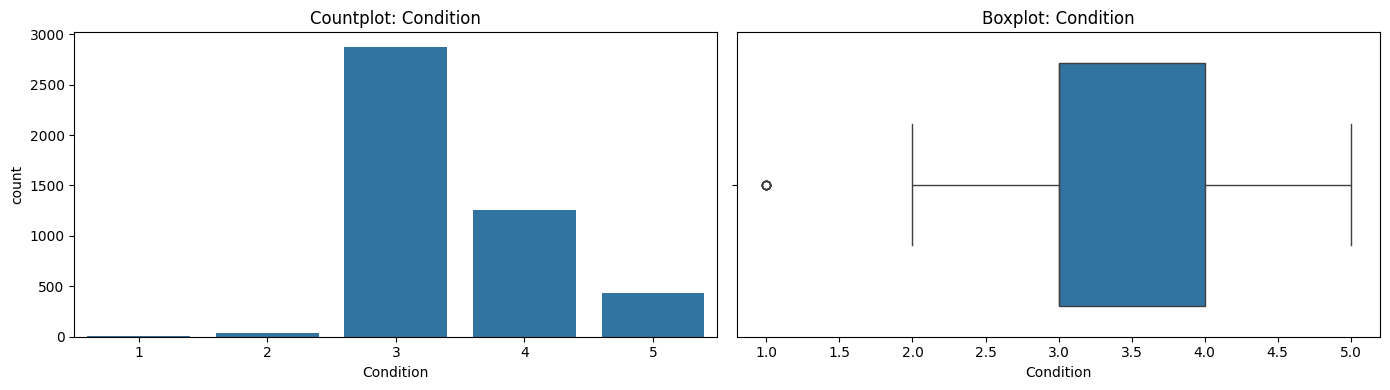


=== Waterfront (ordinal) ===
Waterfront
0    4567
1      33
Name: count, dtype: int64
count    4600.000000
mean        0.007174
std         0.084404
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Waterfront, dtype: float64


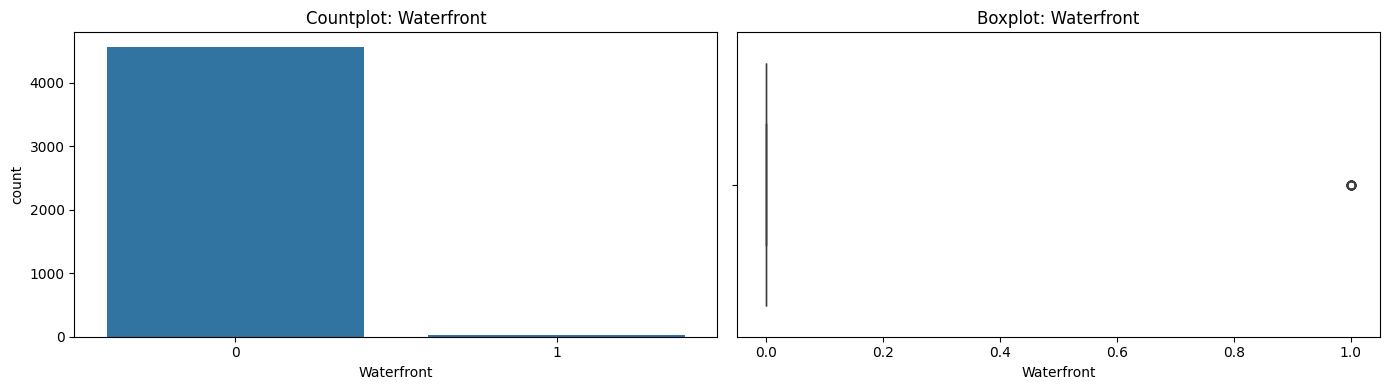

In [5]:
# there are a split between features (every feature is numerical in this dataset) that has continuous values (e.g.: 10,15,1000 etc.) 
# and ordinal features that has some classified value (e.g.: bedroom 1, 2) - they are treated as categorical value. 
# this split help LinearRegression be more efficient.
# for better recognize below is split for these features
continuous_features = [
    'Sqft_Living',
    'Sqft_lot',
    'Sqft_Above',
    'Sqft_Basement'
]
ordinal_features = [
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'view',
    'Condition',
    'Waterfront'
]

def univariate_continuous(df, col):
    print(f"\n=== {col} (continuous) ===")
    print(df[col].describe())
    print(f"Sknewness: {df[col].skew():.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram: {col}")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")

    #QQ-plot
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[2])
    axes[2].set_title(f"QQ-Plot: {col}")

    plt.tight_layout()
    plt.show()

for col in continuous_features:
    univariate_continuous(df, col)


def univariate_ordinal(df, col):
    print(f"\n=== {col} (ordinal) ===")
    print(df[col].value_counts().sort_index())
    print(df[col].describe())

    #--bathroom has to many values, so I have to place make condition for better view of this chart 
    if col == 'Bathrooms':
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

        sns.countplot(x=df[col], ax=ax1, color='skyblue')
        ax1.set_title(f"Countplot: {col}")
        ax1.tick_params(axis='x', rotation=45)

        sns.boxplot(x=df[col], ax=ax2, color='orange')
        ax2.set_title(f"Boxplot: {col}")

    # --rest in normal way
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Countplot (how many reps in each category)
        sns.countplot(x=df[col], ax=axes[0])
        axes[0].set_title(f"Countplot: {col}")

        # Boxplot (Is there any outliers in ordinal values)
        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f"Boxplot: {col}")

        plt.tight_layout()
        plt.show()

for col in ordinal_features:
    univariate_ordinal(df, col)

# 4. Bivariate

# 4a. Bivariate: Continuous features vs Target (Scatterplot + Regplot + Correlation)


--- Analysis: Continuous vs Target ---


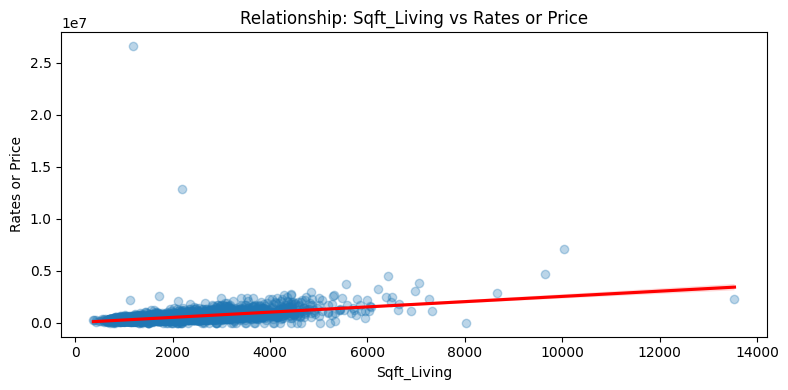

Correlation Sqft_Living with Rates or Price: 0.43


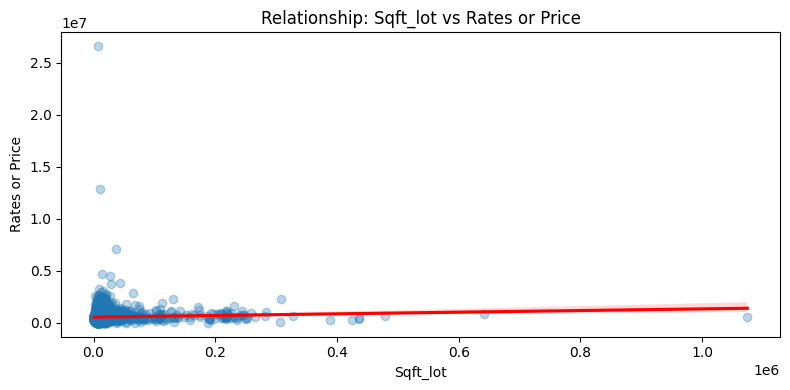

Correlation Sqft_lot with Rates or Price: 0.05


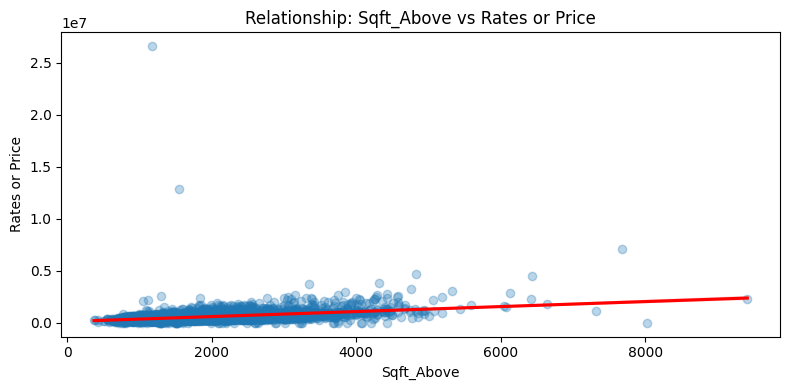

Correlation Sqft_Above with Rates or Price: 0.37


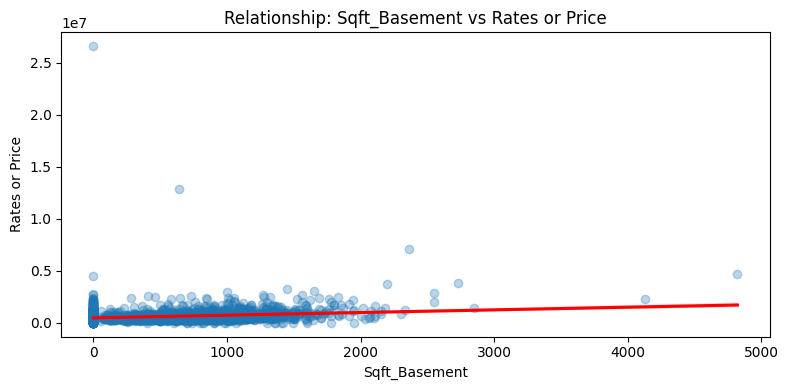

Correlation Sqft_Basement with Rates or Price: 0.21


In [6]:
def analyze_continuous_bivariate(df, continuous_features, target='Rates or Price'):
    print("\n--- Analysis: Continuous vs Target ---")
    for col in continuous_features:
        plt.figure(figsize=(8, 4))

        #Scatterplot + trend line
        sns.regplot(
            data=df, x=col, y=target,
            scatter_kws={'alpha': 0.3},
            line_kws={'color': 'red'}
        )

        plt.title(f"Relationship: {col} vs {target}")
        plt.tight_layout()
        plt.show()

        #Single correlation
        corr = df[col].corr(df[target])
        print(f"Correlation {col} with {target}: {corr:.2f}")

analyze_continuous_bivariate(df, continuous_features)

# 4b. Bivariate: Ordinal features vs Target (Groupby + Boxplot)


--- Analysis: Ordinal vs Target ---

Statistics for Bedrooms:


,mean,median,count
Bedrooms,,,
0,1.195324e+06,1195324.0,2
1,2.740763e+05,262500.0,38
2,3.916219e+05,369500.0,566
3,4.886130e+05,424750.0,2032
4,6.351194e+05,568000.0,1531
5,7.701860e+05,580000.0,353
6,8.173628e+05,665000.0,61
7,1.049429e+06,711500.0,14
8,1.155000e+06,1155000.0,2


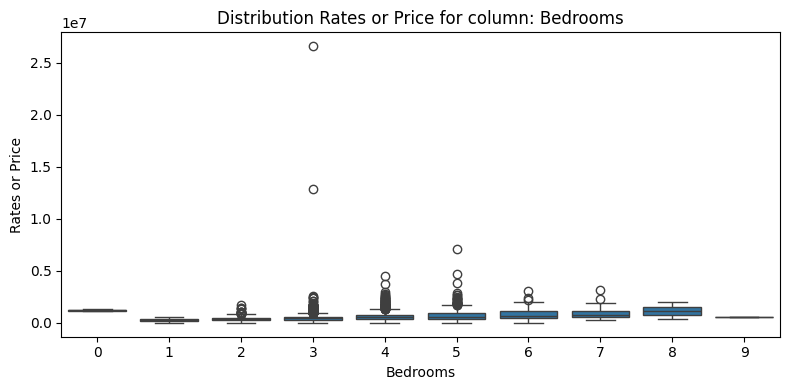


Statistics for Bathrooms:


,mean,median,count
Bathrooms,,,
0.00,1.195324e+06,1195324.0,2
0.75,2.939559e+05,276000.0,17
1.00,3.326206e+05,306000.0,743
1.25,4.611500e+05,516500.0,3
1.50,4.110443e+05,365000.0,291
1.75,4.595496e+05,433000.0,629
2.00,5.268580e+05,437000.0,427
2.25,5.371784e+05,475000.0,419
2.50,5.727052e+05,525000.0,1189


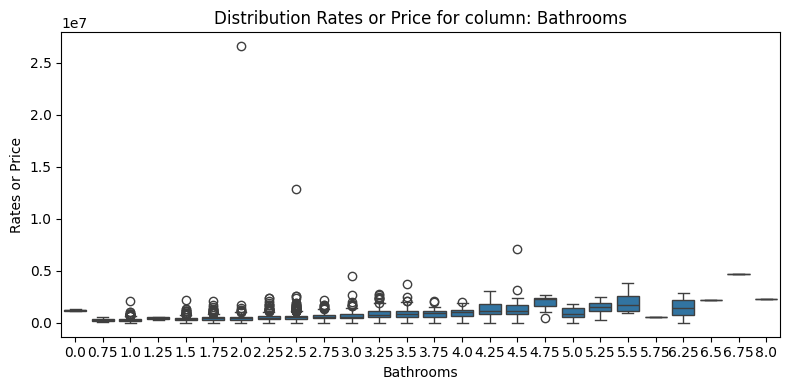


Statistics for Floors:


,mean,median,count
Floors,,,
1.0,457278.687261,390700.0,2174
1.5,578692.700221,535000.0,444
2.0,647985.230122,554000.0,1811
2.5,983863.390244,831500.0,41
3.0,566157.587671,479500.0,128
3.5,829250.000000,829250.0,2


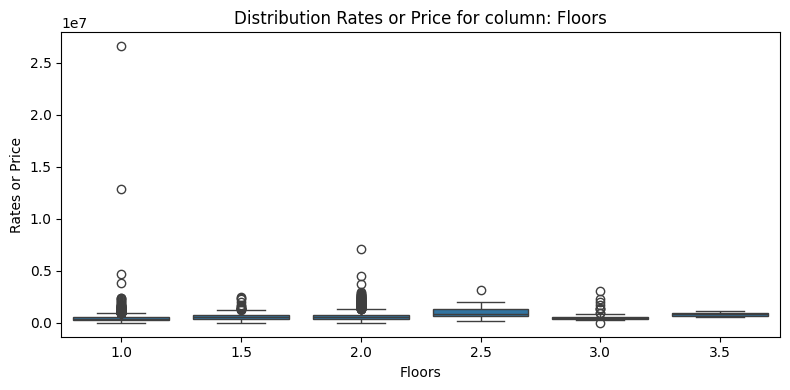


Statistics for view:


,mean,median,count
view,,,
0,5.106849e+05,440912.5,4140
1,8.670110e+05,719000.0,69
2,8.089353e+05,657000.0,205
3,9.982075e+05,890500.0,116
4,1.190667e+06,1007500.0,70


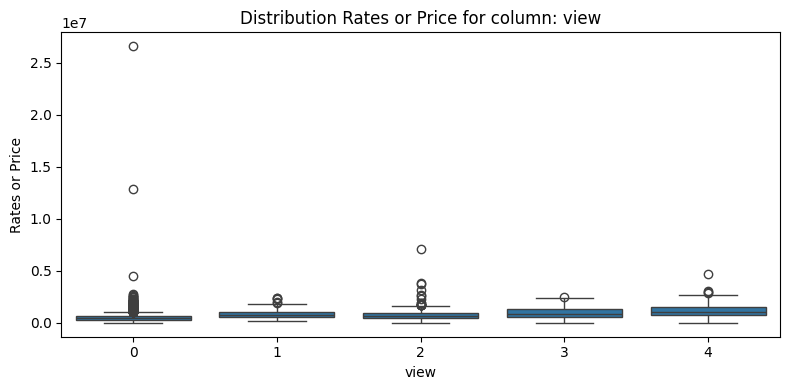


Statistics for Condition:


,mean,median,count
Condition,,,
1,306633.333333,310000.0,6
2,324373.750000,250000.0,32
3,550111.516394,465000.0,2875
4,533647.286072,440000.0,1252
5,637041.322257,550000.0,435


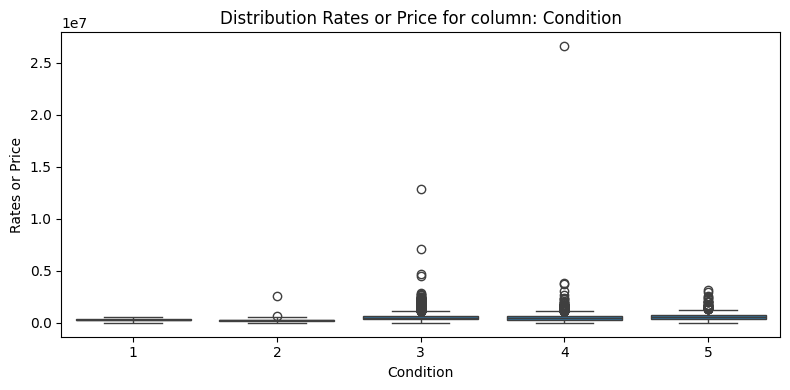


Statistics for Waterfront:


,mean,median,count
Waterfront,,,
0,5.454623e+05,460000.0,4567
1,1.451621e+06,988500.0,33


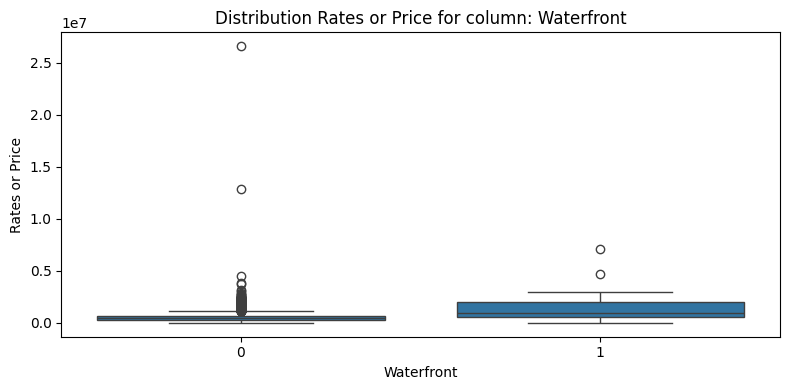

In [10]:
def analyze_ordinal_bivariate(df, ordinal_features, target='Rates or Price'):
    print("\n--- Analysis: Ordinal vs Target ---")
    for col in ordinal_features:

        #Groupby: mean, median, count and categories sorting
        summary = (
            df.groupby(col)[target]
            .agg(['mean', 'median', 'count'])
            .sort_index()
        )

        print(f"\nStatistics for {col}:")
        display(summary)

        # Boxplot
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x=col, y=target)
        plt.title(f"Distribution {target} for column: {col}")
        plt.tight_layout()
        plt.show()

analyze_ordinal_bivariate(df, ordinal_features)



# 4c. Bivariate: Heatmap correlation (for continuous features only)


--- Heatmap Correlation (Continuous Feature only) ---


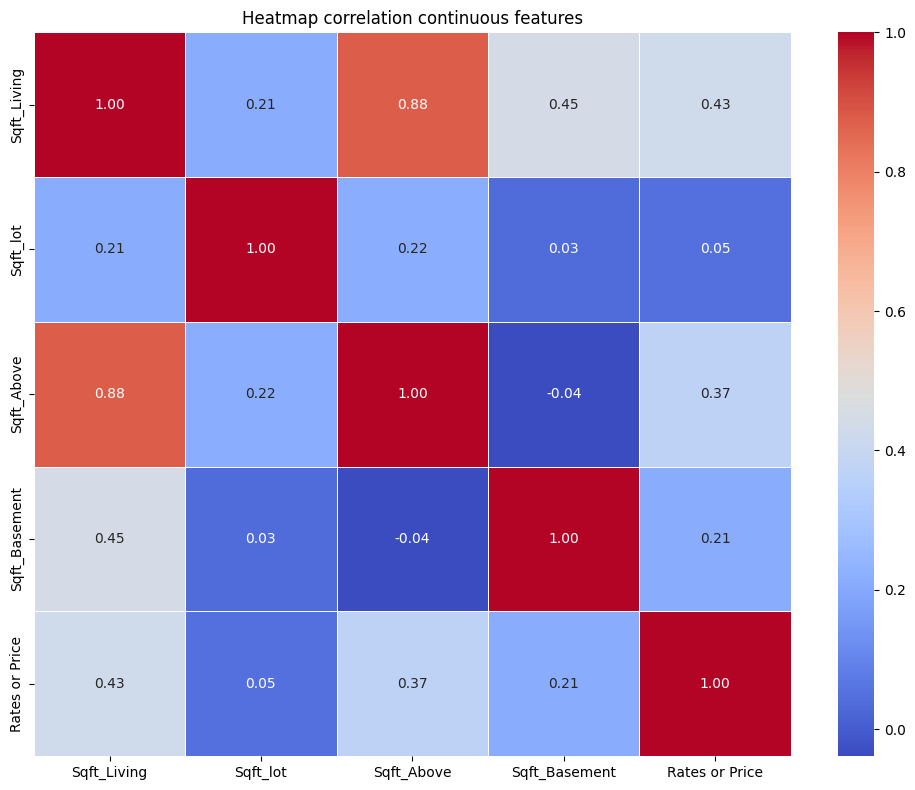

In [12]:
def plot_correclation_heatmap(df, continuous_features, target='Rates or Price'):
    print("\n--- Heatmap Correlation (Continuous Feature only) ---")

    correlation_features = continuous_features + [target]
    corr_matrix = df[correlation_features].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix, annot=True, cmap='coolwarm',
        fmt=".2f", linewidths=0.5
    )
    plt.title("Heatmap correlation continuous features")
    plt.tight_layout()
    plt.show()

plot_correclation_heatmap(df, continuous_features)